<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [1]:
# !gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
# !gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
# !gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
# !gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Разархивируйте zip файл, где содержатся wav файлы датасета.

In [2]:
# !unzip -n /content/sound_classification_dataset.zip

In [3]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [4]:
train_df = pd.read_csv("content/train.csv")
valid_df = pd.read_csv("content/valid.csv")
test_df = pd.read_csv("content/test.csv")

Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [ ]:
# !pip install torch_audiomentations

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for julius: filename=julius-0.2.7-py3-none-any.whl size=22017 sha256=20d4acbef088b63c0a6a2cf2b518a5f2403764a7a833fb6e3cef6b74f002ae9d
  Stored in directory: c:\users\pong\appdata\local\pip\cache\wheels\de\c1\ca\544dafe48401e8e2e17064dfe465a390fca9e8720ffa12e744
Successfully built julius

   ---------------------------------------- 4/4 [torch_audiomentations]



In [8]:
import torch
import torchaudio
from torch.utils.data import Dataset
import pandas as pd
import os
from torch_audiomentations import (Compose, AddColoredNoise, Gain, PitchShift,
    Shift, PolarityInversion, TimeInversion)

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files with caching."""

    def __init__(self, dataframe, do_augmentation=False):
        self._dataframe = dataframe
        self._do_augmentation = do_augmentation
        self._cache = {}  # Initialize cache

        # Check if 'category' column exists
        if 'category' in self._dataframe.columns:
            self.classes = sorted(self._dataframe['category'].unique())
            self.class_to_index = {cls: i for i, cls in enumerate(self.classes)}
            self._has_labels = True
        else:
            # For test set, no labels
            self.classes = None
            self.class_to_index = None
            self._has_labels = False

        # Define augmentations
        self.augment = Compose(
            transforms=[
                AddColoredNoise(), Gain(), PitchShift(sample_rate=16000),
                Shift(), PolarityInversion(), TimeInversion(),
                # Add more augmentations here if needed
            ]
        )

    def __len__(self):
        return len(self._dataframe)

    def __getitem__(self, index):
        if index in self._cache:
            signal, label = self._cache[index]
        else:
            # 1. Get the file path and label (if available)
            audio_file_path = f"content/sound_classification_dataset/{self._dataframe.iloc[index]['filename']}"

            # 2. LOAD: Load the raw audio file
            signal, sample_rate = torchaudio.load(audio_file_path)

            # 3. PREPROCESS: Apply the preprocessing steps
            signal = self._resample(signal, sample_rate) # Resample to the sample rate 16000
            signal = self._stereo_to_mono(signal) # Converts (channels, samples) -> (samples,)
            signal = self._cut_or_pad(signal) # State fixed length

            # Cache the processed signal and label (if available)
            if self._has_labels:
                label_str = self._dataframe.iloc[index]['category']
                label = self.class_to_index[label_str]
            else:
                label = None # No label for test set
            self._cache[index] = (signal, label)


        # 4. AUGMENT: Apply augmentations only if training and do_augmentation is True
        # Augmentations are applied *after* loading from cache, on the base signal
        if self._do_augmentation and self._has_labels: # Only augment if training data has labels
             signal = self._augmentation(signal.clone()) # Clone to avoid modifying cached data

        signal = signal.squeeze(1)

        # 5. RETURN: Return signal and label (if available)
        if self._has_labels:
            label_str = self._dataframe.iloc[index]['category']
            label_index = self.class_to_index[label_str]
            return signal, label_index
        else:
            # For test set, return just the signal
            return signal


    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        signal = torchaudio.transforms.Resample(original_sr, 16000)(signal)
        return signal

    def _stereo_to_mono(self, signal):
        signal = torch.mean(signal, dim=0, keepdim=True)
        return signal

    def _cut_or_pad(self, signal):
        # Assuming a fixed length of 80000 samples
        target_length = 80000
        if signal.shape[-1] < target_length:
            padding = target_length - signal.shape[-1]
            signal = torch.nn.functional.pad(signal, (0, padding))
        elif signal.shape[-1] > target_length:
            signal = signal[..., :target_length]
        return signal

    def _augmentation(self, signal):
        # torch_audiomentations expects shape (batch_size, num_channels, num_samples)
        # Since we are processing one sample at a time, we add a batch dimension
        signal = signal.unsqueeze(0)
        signal = self.augment(samples=signal, sample_rate=16000)
        signal = signal.squeeze(0) # Remove the batch dimension after augmentation
        return signal

In [9]:
train_dataset = SimpleAudioDataset(train_df, do_augmentation=True)
valid_dataset = SimpleAudioDataset(valid_df)

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class SoundClassificatonModel(nn.Module):
    """A simple model that processes raw waveforms."""

    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=21, stride=1, padding=10)
        self.pool1 = nn.MaxPool1d(kernel_size=20, stride=20)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=21, stride=1, padding=10)
        self.pool2 = nn.MaxPool1d(kernel_size=20, stride=20)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=21, stride=1, padding=10)
        self.pool3 = nn.MaxPool1d(kernel_size=20, stride=20)
        # Assuming the input length is 80000, after 3 pooling layers with stride 4, the length will be 80000 / (20*20*20) = 10
        self.fc1 = nn.Linear(in_features=64 * (80000 // (20*20*20)), out_features=128) # Adjust input features based on input size and pooling
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)


    def forward(self, x):
        # x is (batch_size, 1, sequence_length)
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [11]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


Epoch 1/20, Train Loss: 1.6088, Train Acc: 0.1417, Valid Loss: 1.5679, Valid Acc: 0.2250
Epoch 2/20, Train Loss: 1.5555, Train Acc: 0.1917, Valid Loss: 1.4132, Valid Acc: 0.3250
Epoch 3/20, Train Loss: 1.4152, Train Acc: 0.4417, Valid Loss: 1.1563, Valid Acc: 0.4750
Epoch 4/20, Train Loss: 1.2798, Train Acc: 0.4500, Valid Loss: 1.2166, Valid Acc: 0.5500
Epoch 5/20, Train Loss: 1.2619, Train Acc: 0.5583, Valid Loss: 0.9701, Valid Acc: 0.5500
Epoch 6/20, Train Loss: 1.1507, Train Acc: 0.6167, Valid Loss: 0.9983, Valid Acc: 0.6500
Epoch 7/20, Train Loss: 0.9398, Train Acc: 0.7167, Valid Loss: 1.0358, Valid Acc: 0.6750
Epoch 8/20, Train Loss: 1.0832, Train Acc: 0.6083, Valid Loss: 0.7511, Valid Acc: 0.8000
Epoch 9/20, Train Loss: 0.8890, Train Acc: 0.7500, Valid Loss: 0.6295, Valid Acc: 0.8000
Epoch 10/20, Train Loss: 0.8281, Train Acc: 0.7083, Valid Loss: 0.7100, Valid Acc: 0.7500
Epoch 11/20, Train Loss: 0.8048, Train Acc: 0.7667, Valid Loss: 0.6129, Valid Acc: 0.8000
Epoch 12/20, Train 

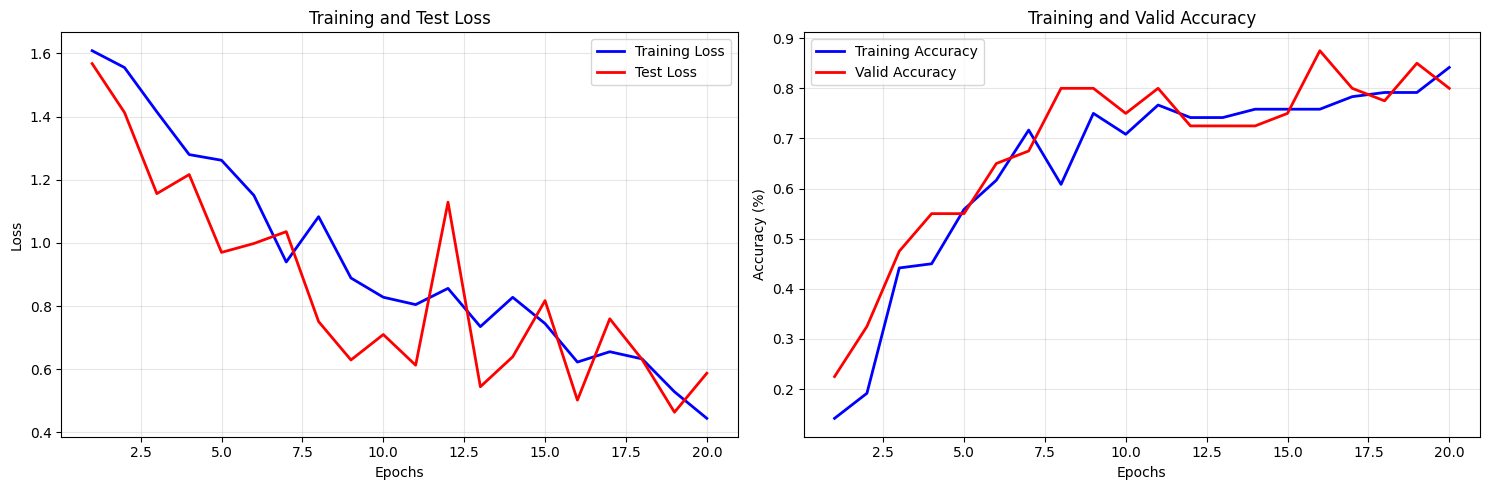

In [12]:
from torch.utils.data import DataLoader
from IPython.display import clear_output
import numpy as np

# Initialize datasets & dataloaders
train_data = SimpleAudioDataset(train_df, do_augmentation=True)
valid_data = SimpleAudioDataset(valid_df)
test_data = SimpleAudioDataset(test_df)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=40, shuffle=False)
test_loader = DataLoader(test_data, shuffle=False)

# Model, Loss, Optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificatonModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

n_epochs = 20
for epoch in range(n_epochs):
    # Train
    model.train()
    running_train_loss = 0.0
    running_train_correct = 0
    total_train_samples = 0

    for signals, labels in train_loader:
        # load data to device
        # signals and labels are already tensors from the DataLoader
        signals = signals.to(device)
        labels = labels.to(device)
        # Forward pass
        predictions = model(signals)
        train_loss = criterion(predictions, labels)

        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # Accumulate training metrics
        running_train_loss += train_loss.item() * signals.size(0)
        running_train_correct += (predictions.argmax(dim=1) == labels).sum().item()
        total_train_samples += signals.size(0)

    # Calculate average train loss and accuracy for this epoch
    epoch_train_loss = running_train_loss / total_train_samples
    epoch_train_acc = running_train_correct / total_train_samples

    # Evaluation
    model.eval()
    running_valid_loss = 0.0
    running_valid_correct = 0
    total_valid_samples = 0

    with torch.no_grad():
        for signals, labels in valid_loader:
            # load data to device
            # signals and labels are already tensors from the DataLoader
            signals = signals.to(device)
            labels = labels.to(device)

            # Forward pass
            predictions = model(signals)
            valid_loss = criterion(predictions, labels)

            # Accumulate validation metrics
            running_valid_loss += valid_loss.item() * signals.size(0)
            running_valid_correct += (predictions.argmax(dim=1) == labels).sum().item()
            total_valid_samples += signals.size(0)

    # Calculate average valid loss and accuracy for this epoch
    epoch_valid_loss = running_valid_loss / total_valid_samples
    epoch_valid_acc = running_valid_correct / total_valid_samples

    # Store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

    # Print epoch metrics
    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, Valid Loss: {epoch_valid_loss:.4f}, Valid Acc: {epoch_valid_acc:.4f}")

# Plot metrics
plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
# clear_output(wait=True)

In [13]:
print(f"Best Train Accuracy = {max(train_accuracies):.2f}")
print(f"Best Valid Accuracy = {max(valid_accuracies):.2f}")

Best Train Accuracy = 0.84
Best Valid Accuracy = 0.88


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cpu
ESC-50 Audio Classification Demo!


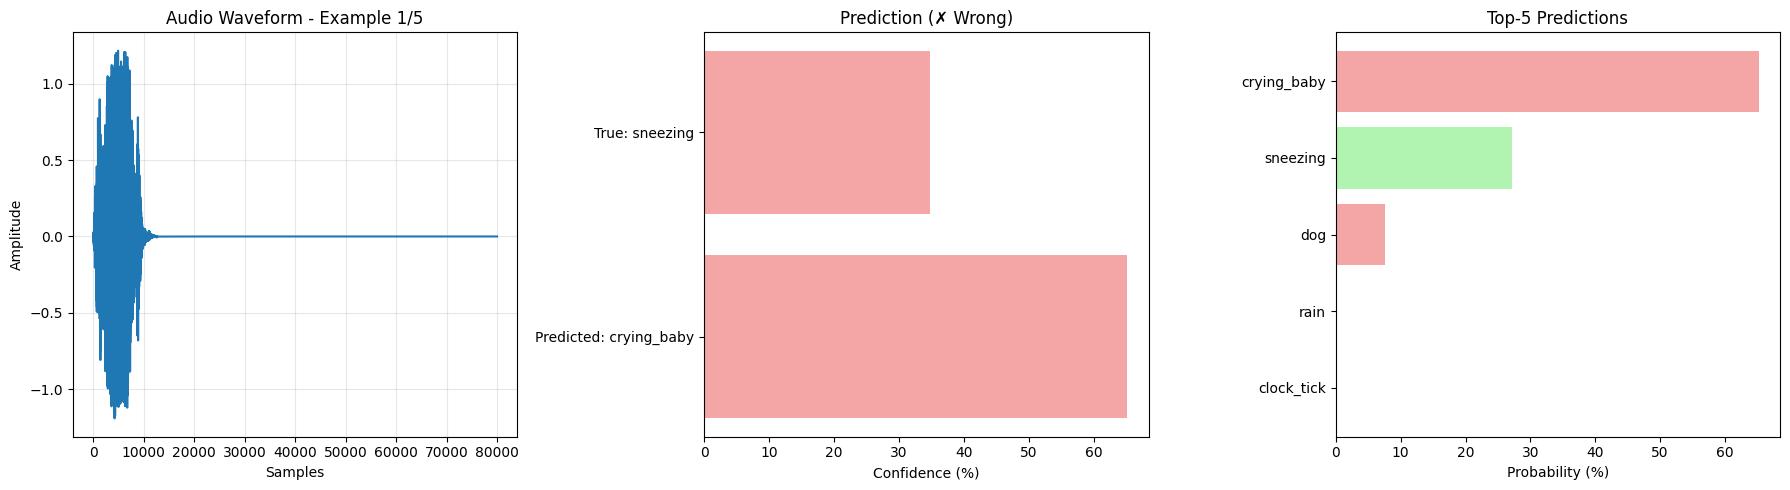

Playing: sneezing


Prediction: crying_baby (65.21%)
True label: sneezing
Correct: False


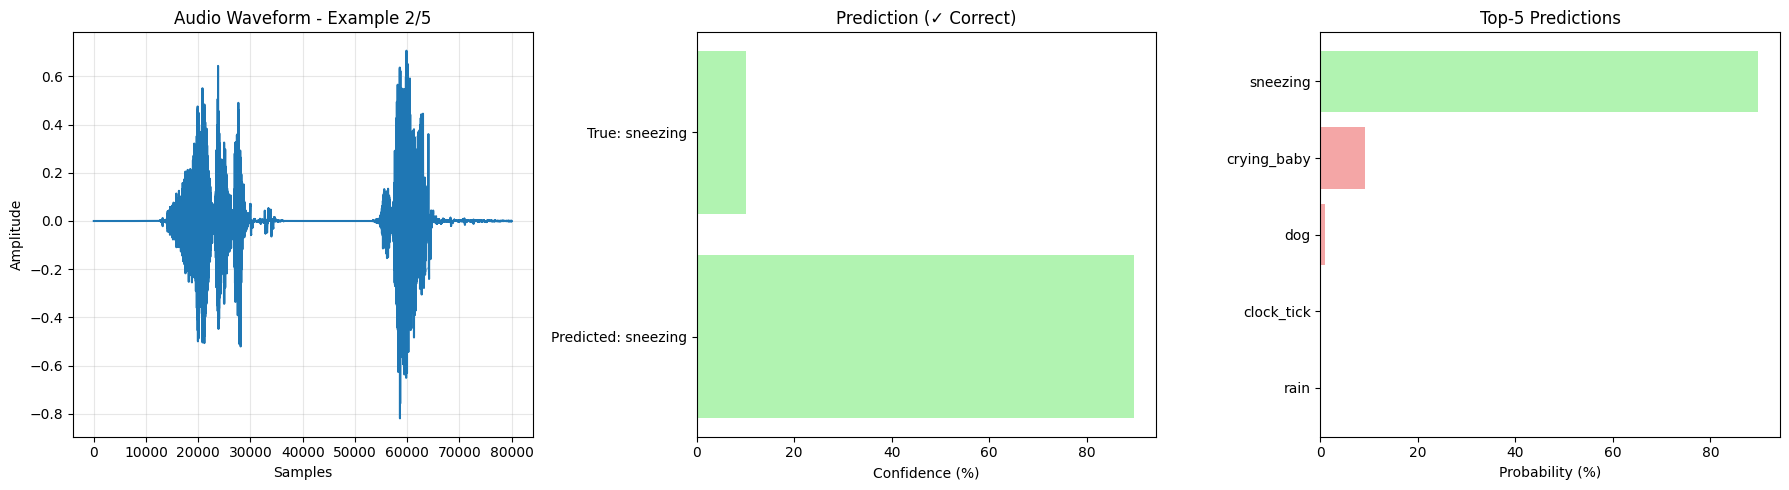

Playing: sneezing


Prediction: sneezing (89.79%)
True label: sneezing
Correct: True


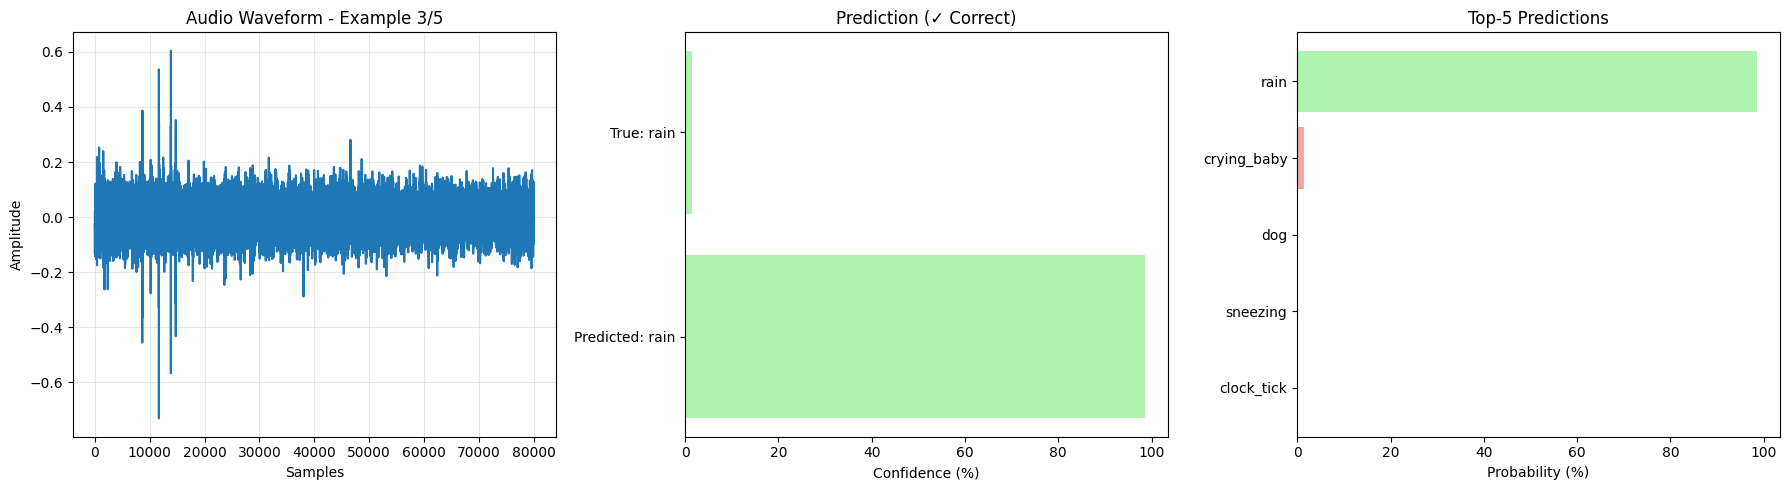

Playing: rain


Prediction: rain (98.55%)
True label: rain
Correct: True


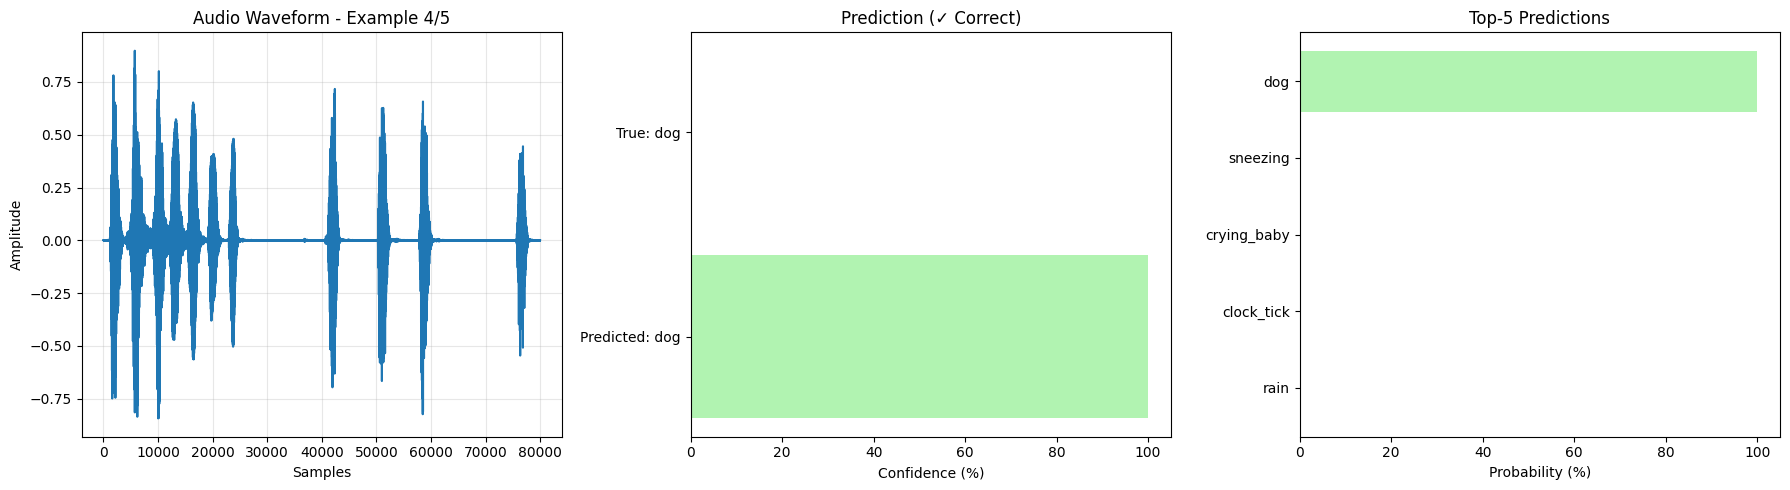

Playing: dog


Prediction: dog (100.00%)
True label: dog
Correct: True


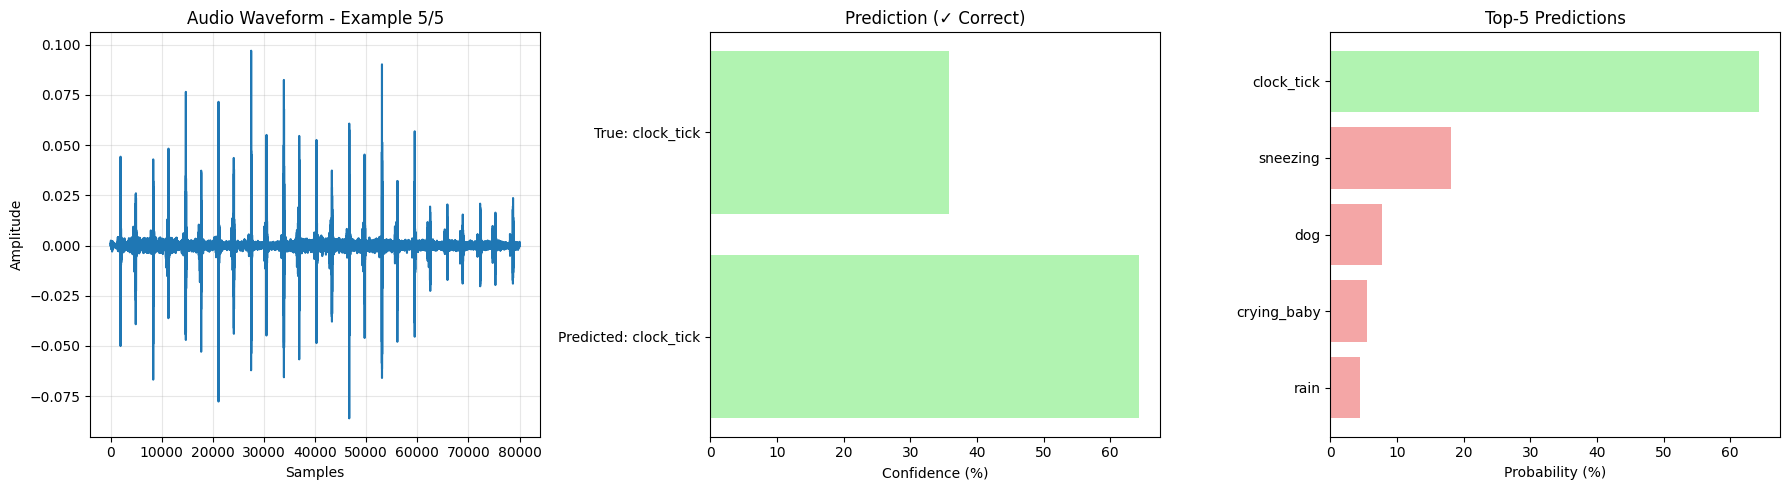

Playing: clock_tick


Prediction: clock_tick (64.26%)
True label: clock_tick
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 32/40
Accuracy: 80.00%


In [14]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [ ]:
# Make predictions on the test set
model.eval()
y_test_pred_indices = []

# Get the class mapping from the training dataset
class_index_to_class = {i: cls for cls, i in train_data.class_to_index.items()}

with torch.no_grad():
    for signals in test_loader:
        # load data to device
        signals = signals.to(device)

        # Forward pass
        predictions = model(signals)
        _, predicted_indices = torch.max(predictions.data, 1)
        y_test_pred_indices.extend(predicted_indices.cpu().numpy())

# Convert predicted indices back to class names
y_test_pred = [class_index_to_class[index] for index in y_test_pred_indices]

In [ ]:
submission = pd.read_csv("/content/test.csv")
submission['category'] = y_test_pred
submission.to_csv("/content/submission.csv", index=False)

### **Report**

Сначала сделал датасет без аугментаций и простую сверточную модель на 1d свертках: (conv + relu + max_pool) x3 + fc + fc.


Первый вариант переобучался, поэтому я добавил много аугментаций, увеличил (conv + relu + max_pool) до x5 и добавил dropout между fc слоями.

Второй вариант не захотел обучаться вообще, поэтому я потестил звук после аугментаций, там было слишком непонятно даже мне, поэтому часть аугментаций убрал. Также убрал dropout между fc слоями и вернул x3 на (conv + relu + max_pool), но увеличил размер сверток 3 -> 21 для лучшего извлечения информации и размер макспула 2 -> 20 для уменьшения размерности перед первым fc слоем - получил финальный результат и 80% на Stepik.